In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import folium

In [2]:
place = "Kolkata, West Bengal, India"

graph = ox.graph_from_place(place, network_type="drive")

print("Graph loaded successfully!")

Graph loaded successfully!


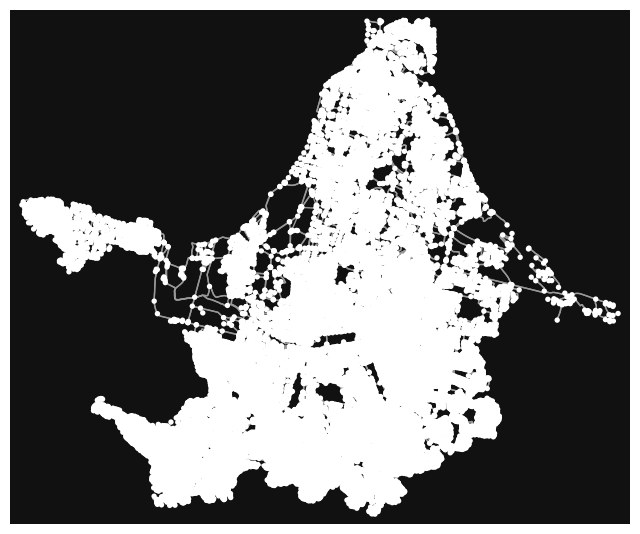

In [3]:
fig, ax = ox.plot_graph(graph)

In [5]:
# Convert place names to coordinates
start_location = ox.geocode("Park Street, Kolkata")
end_location = ox.geocode("Apollo Hospital, Kolkata")

# Convert coordinates to graph nodes
orig_node = ox.distance.nearest_nodes(graph, start_location[1], start_location[0])
dest_node = ox.distance.nearest_nodes(graph, end_location[1], end_location[0])

In [6]:
#Apply the A* Algorithm

In [7]:
route = nx.astar_path(
    graph,
    orig_node,
    dest_node,
    weight="length"
)

print("Route calculated successfully")

Route calculated successfully


In [ ]:
"""orig_node → starting node

dest_node → destination node

weight="length" → minimize road distance

The algorithm now finds the shortest path through Kolkata roads."""

'orig_node → starting node\n\ndest_node → destination node\n\nweight="length" → minimize road distance\n\nThe algorithm now finds the shortest path through Kolkata roads.'

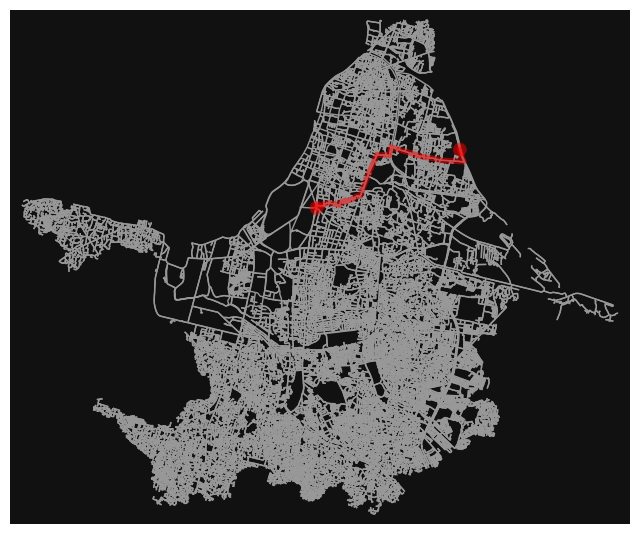

In [9]:
#Plot the route on map
fig, ax = ox.plot_graph_route(
    graph,
    route,
    route_linewidth=4,
    node_size=0
)

Kolkata road network

A highlighted route from Park Street → Apollo Hospital

In [ ]:
#We simulate traffic by modifying edge weights.
for u, v, key, data in graph.edges(keys=True, data=True):

    road_length = data["length"]

    traffic_factor = 1.3
"""100 meters
Without traffic:
cost = 100
With traffic factor:
cost = 100 × 1.3 = 130"""
    
data["traffic_weight"] = road_length * traffic_factor

Now each road has a traffic-adjusted cost.

In [13]:
#Run A* Using Traffic Weight
route_traffic = nx.astar_path(
    graph,
    orig_node,
    dest_node,
    weight="traffic_weight"
)

print("Traffic-aware route calculated")

Traffic-aware route calculated


Now the route avoids high-cost roads.

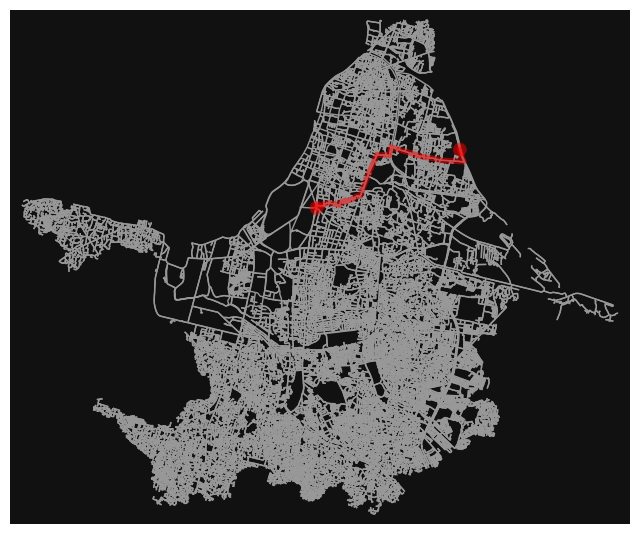

In [15]:
#Visualize the Traffic Route
fig, ax = ox.plot_graph_route(
    graph,
    route_traffic,
    route_color="red",
    route_linewidth=4,
    node_size=0
)

Now we will see the optimal ambulance path considering traffic.

In [22]:
# Create Interactive Map
import folium
import networkx as nx

# Extract coordinates of route nodes
route_coords = [(graph.nodes[node]['y'], graph.nodes[node]['x']) for node in route_traffic]

# Create map centered at start location
map_route = folium.Map(location=route_coords[0], zoom_start=13)

# Draw route line
folium.PolyLine(
    route_coords,
    color="red",
    weight=5,
    opacity=0.8
).add_to(map_route)

# Add start marker
folium.Marker(
    route_coords[0],
    popup="Ambulance Start",
    icon=folium.Icon(color="green")
).add_to(map_route)

# Add destination marker
folium.Marker(
    route_coords[-1],
    popup="Hospital",
    icon=folium.Icon(color="red")
).add_to(map_route)

# Save map
map_route.save("kolkata_ambulance_route.html")

print("Map saved successfully!")

# Calculate route distance
route_length = nx.path_weight(graph, route_traffic, weight="length")

print("Route distance (meters):", route_length)

# Convert to km
distance_km = route_length / 1000

# Assume ambulance speed
speed_kmph = 40

# Calculate travel time
travel_time = (distance_km / speed_kmph) * 60

print("Estimated travel time (minutes):", round(travel_time, 2))

Map saved successfully!
Route distance (meters): 7848.77655379638
Estimated travel time (minutes): 11.77
